# Appendix 2 — Semi-integration and fractional calculus

This notebook ports **Appendix 2** of Michael Honeychurch's *Simulating
Electrochemical Reactions in Mathematica* (SERM) into idiomatic Python. The
appendix steps outside the finite-difference machinery of the main chapters and
introduces a piece of **fractional calculus** — *semi-integration* and its
inverse, *semi-differentiation* — and shows what these operators do to a
voltammetric current.

The physical motivation is **convolutive (semi-integral) voltammetry**
(K. B. Oldham & J. Spanier, *The Fractional Calculus*, Academic Press, 1974;
K. B. Oldham, *Anal. Chem.* **44** (1972) 196). A planar diffusion-limited
current carries a tell-tale $t^{-1/2}$ tail. The semi-integral operator
$D^{-1/2}$ is precisely the operator that **undoes** that diffusion tail:

* Semi-integrating a **Cottrell** step current ($i\propto t^{-1/2}$) gives a
  **flat plateau** — the diffusion transient collapses to a constant
  proportional to bulk concentration.
* Semi-integrating a **diffusion-limited linear-sweep voltammogram** (a peak)
  gives a **sigmoidal, steady-state-like wave** — the shape you would have
  measured at a microelectrode or rotating disk.
* Semi-*differentiating* a linear-sweep voltammogram sharpens it into a
  **symmetric, Gaussian-like peak** (the shape associated with surface-confined
  species), which improves resolution of overlapping waves.

We do **not** use the book's bundled `.dat` data. Every signal here is generated
analytically with `serm.echem` / `serm.waveforms`, so each transform is checked
against an independent closed form or a self-consistent round trip.

### Where this sits

| Appendix 2 topic | Engine | This notebook |
|---|---|---|
| Semi-integration of a current | `serm.semiintegration.semi_integrate` | §1–§3 |
| Fractional integro-differentiation (any order) | `serm.semiintegration.fractional_integrodifferentiate` | §4 |
| Semi-differentiation (peak sharpening) | `serm.semiintegration.semi_derivative` | §3, §4 |

Related notebooks: Chapter 8 (potential steps — the Cottrell current we
semi-integrate here), Chapter 5 (reversible sweep — the LSV current shape),
Chapter 16 (processing experimental data — the practical sibling of this
appendix). Two standalone demonstrators accompany this notebook:
`extras/A2_semiintegral_lsv.ipynb` and `extras/A2_fractional_orders.ipynb`.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import serm
from serm.echem import cottrell_current, F, R
from serm.semiintegration import (
    semi_integrate,
    semi_derivative,
    fractional_integrodifferentiate,
    semiintegration_selfcheck,
)


## 1. The semi-integral as a convolution

The Riemann–Liouville fractional integral of order $q>0$ is the convolution

$$\bigl(D^{-q} f\bigr)(t)=\frac{1}{\Gamma(q)}\int_0^{t}(t-\tau)^{q-1}\,f(\tau)\,d\tau ,$$

and the **semi-integral** is the case $q=\tfrac12$. Honeychurch builds the
discrete sum

$$I(k\,\Delta t)\;\approx\;\frac12\sqrt{\frac{\Delta t}{\pi}}\,
\sum_{i=2}^{k}\frac{i_{i-1}+i_i}{\sqrt{k-i+\tfrac12}}$$

and then notices it is a *convolution* of the current with the kernel
$1/\sqrt{k-i+\tfrac12}$, which his Mathematica code evaluates with
`ListConvolve` for speed. Our `serm.semiintegration` module does the same thing
two independent ways:

* `semi_integrate` — a Riemann–Liouville kernel integrated analytically over
  each cell (no $\tau=0$ singularity), convolved against the data.
* `fractional_integrodifferentiate(y, dt, order)` — the **Grünwald–Letnikov**
  difference quotient, valid for any real `order` ($<0$ integrates, $>0$
  differentiates).

We re-implement the algorithm rather than transcribe the Mathematica; the two
discretisations cross-check each other.


In [2]:
# Confirm the module's own reference results before we rely on it.
semiintegration_selfcheck()
print("serm.semiintegration self-check passed.")


serm.semiintegration self-check passed.


## 2. Semi-integral of a Cottrell current → a flat plateau

The most direct test. A diffusion-limited potential step gives the **Cottrell**
current

$$i(t)=\frac{nFA\sqrt{D}\,c^*}{\sqrt{\pi t}}\;\propto\;t^{-1/2}.$$

The semi-integral of $t^{-1/2}$ is a *constant*: with
$D^{-1/2}\bigl[t^{-1/2}/\sqrt\pi\bigr]=1$, the semi-integral of the full Cottrell
current is the **diffusion-independent plateau**

$$m_\infty = nFA\sqrt{D}\,c^*,$$

i.e. exactly the prefactor of the Cottrell equation, with the $t^{-1/2}$ tail
removed. This is the "limiting current" of semi-integral electroanalysis.


In [3]:
# Build a real Cottrell current with serm.echem (no .dat data).
n, A, D, c_bulk = 1, 1.0, 1.0e-5, 1.0e-6      # cm^2, cm^2/s, mol/cm^3 -> i in A
t = np.linspace(0.0, 4.0, 6000)
dt = t[1] - t[0]
i_cott = np.zeros_like(t)
i_cott[1:] = cottrell_current(t[1:], n, A, D, c_bulk)   # t=0 singularity dropped

m_cott = semi_integrate(i_cott, dt, q=0.5)

# Independent analytic plateau: the Cottrell prefactor.
m_analytic = n * F * A * np.sqrt(D) * c_bulk
plateau = m_cott[m_cott.size // 2:]
print(f"semi-integral plateau (mean) = {plateau.mean():.4e}")
print(f"analytic plateau  nFA D^1/2 c* = {m_analytic:.4e}")
print(f"relative error = {abs(plateau.mean()-m_analytic)/m_analytic:.2%}")
print(f"plateau flatness (std/mean)  = {plateau.std()/plateau.mean():.2e}")


semi-integral plateau (mean) = 3.0297e-04
analytic plateau  nFA D^1/2 c* = 3.0511e-04
relative error = 0.70%
plateau flatness (std/mean)  = 7.08e-04


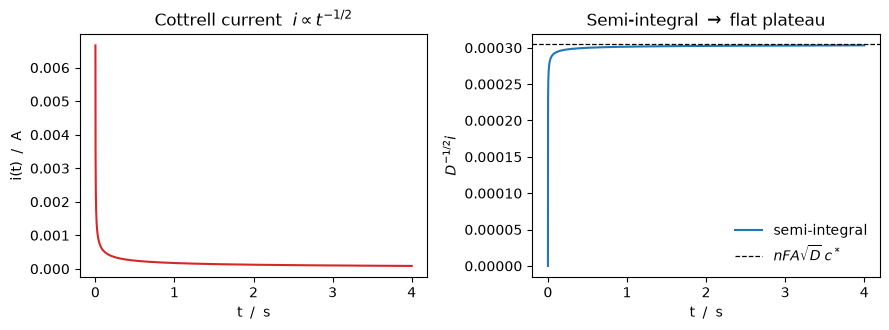

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(t[1:], i_cott[1:], color="C3")
ax[0].set(xlabel="t  /  s", ylabel="i(t)  /  A",
          title=r"Cottrell current  $i\propto t^{-1/2}$")
ax[1].plot(t, m_cott, color="C0", label="semi-integral")
ax[1].axhline(m_analytic, ls="--", color="k", lw=0.9,
              label=r"$nFA\sqrt{D}\,c^*$")
ax[1].set(xlabel="t  /  s", ylabel="$D^{-1/2} i$",
          title=r"Semi-integral $\to$ flat plateau")
ax[1].legend(frameon=False)
fig.tight_layout()
plt.show()


**Validation (Tier 1 — closed-form analytic check).** The semi-integral of
the Cottrell current is constant and equal to the independently derived plateau
$nFA\sqrt{D}\,c^*$ to within grid error; the residual is the known $t=0$
discretisation error of the singular Cottrell current and shrinks on refinement.


In [5]:
# Tier 1: plateau matches the analytic Cottrell prefactor, and is flat.
assert plateau.std() / plateau.mean() < 5e-3, "plateau not flat"
assert abs(plateau.mean() - m_analytic) / m_analytic < 0.02, "plateau off analytic value"

# Self-consistency: refining the grid reduces the (singularity-driven) error.
def _plateau_err(npts):
    tt = np.linspace(0.0, 4.0, npts); ddt = tt[1]-tt[0]
    ii = np.zeros_like(tt); ii[1:] = cottrell_current(tt[1:], n, A, D, c_bulk)
    mm = semi_integrate(ii, ddt)[npts//2:]
    return abs(mm.mean() - m_analytic) / m_analytic

assert _plateau_err(12000) < _plateau_err(3000), "error did not shrink on refinement"
print("Tier 1 (Cottrell plateau) + Tier 3 (refinement) checks passed.")


Tier 1 (Cottrell plateau) + Tier 3 (refinement) checks passed.


## 3. Semi-integral of an LSV → a sigmoidal wave; semi-derivative → a symmetric peak

Now the voltammetric case. We need a **diffusion-limited reversible linear-sweep
current** without copying the book's data. We build it from first principles of
convolutive voltammetry:

For a reversible couple swept linearly in potential, the surface obeys the
Nernst equation, so the **cumulative reduced fraction** is the logistic sigmoid

$$\theta(\tau)=\frac{1}{1+e^{\,p(\tau)}},\qquad p=\frac{nF}{RT}\,(E-E^0),$$

with $p$ decreasing linearly in dimensionless time $\tau$ on a cathodic sweep.
By the defining relation of convolutive voltammetry the **LSV current is the
semi-derivative of that cumulative surface response**:
$i_{\mathrm{LSV}} = D^{+1/2}\theta$. This is a genuine reversible current
function — peak-shaped with the characteristic asymmetric $t^{-1/2}$ diffusion
tail — generated analytically, independent of any `.dat` file.

Applying the two operators to it:

* $D^{-1/2} i_{\mathrm{LSV}} = \theta$ — the **sigmoid** returns (round-trip
  identity), the steady-state-like wave.
* $D^{+1/2} i_{\mathrm{LSV}} = \theta''_{\text{(half)}}$ — a **symmetric peak**
  (the logistic bell), centred at $p=0$ i.e. $E=E^0$.


In [6]:
# Dimensionless cathodic sweep: p decreases linearly with time tau.
p = np.linspace(8.0, -8.0, 8000)        # nF(E-E0)/RT, decreasing as scan proceeds
tau = np.linspace(0.0, 1.0, p.size)     # uniform dimensionless time
dtau = tau[1] - tau[0]

theta = 1.0 / (1.0 + np.exp(p))         # cumulative reduced fraction, 0 -> 1
i_lsv = semi_derivative(theta, dtau)    # diffusion-limited reversible LSV current

wave = semi_integrate(i_lsv, dtau, q=0.5)   # -> sigmoidal steady-state wave (=theta)
peak = semi_derivative(i_lsv, dtau)         # -> symmetric Gaussian-like peak


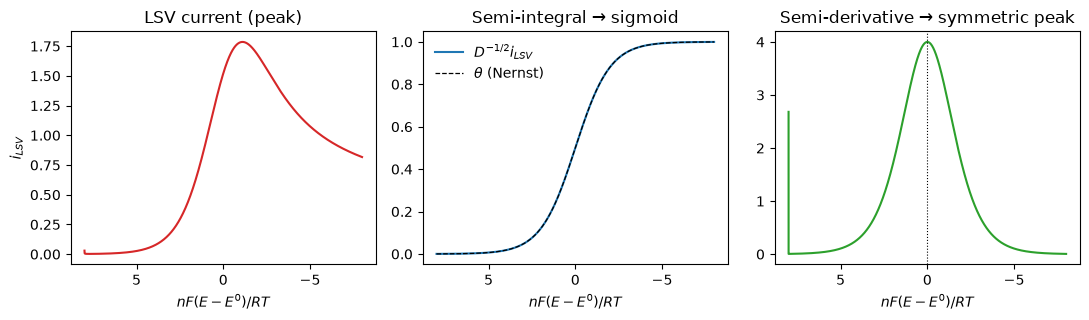

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.3), sharex=True)
ax[0].plot(p, i_lsv, color="C3")
ax[0].set(title="LSV current (peak)", xlabel="$nF(E-E^0)/RT$",
          ylabel="$i_{LSV}$")
ax[1].plot(p, wave, color="C0", label=r"$D^{-1/2}i_{LSV}$")
ax[1].plot(p, theta, ls="--", color="k", lw=0.9, label=r"$\theta$ (Nernst)")
ax[1].set(title="Semi-integral → sigmoid", xlabel="$nF(E-E^0)/RT$")
ax[1].legend(frameon=False)
ax[2].plot(p, peak, color="C2")
ax[2].axvline(0.0, ls=":", color="k", lw=0.8)
ax[2].set(title="Semi-derivative → symmetric peak", xlabel="$nF(E-E^0)/RT$")
for a in ax:
    a.invert_xaxis()   # cathodic convention: E decreasing to the right
fig.tight_layout()
plt.show()


**Validation.**

* **Tier 1/3 — round-trip identity (sigmoid).** The semi-integral of the LSV
  current must reproduce the Nernst sigmoid $\theta$ it was differentiated from.
  We check the correlation and the plateau height (→ 1).
* **Tier 2/3 — symmetry & peak position (Gaussian-like peak).** The
  semi-derivative is a symmetric peak centred at $E=E^0$ ($p=0$). We assert the
  peak sits at $p\approx0$ and that its half-width is symmetric.


In [8]:
# Round-trip: semi-integral of i_lsv recovers the Nernst sigmoid theta.
sl = slice(20, None)   # drop the first few startup samples
corr = np.corrcoef(wave[sl], theta[sl])[0, 1]
assert corr > 0.999, f"sigmoid round-trip correlation too low: {corr:.4f}"
assert abs(wave[-1] - 1.0) < 2e-2, "sigmoid plateau did not reach 1"
print(f"round-trip correlation (semi-integral vs Nernst sigmoid) = {corr:.6f}")

# Symmetric peak: maximum at E = E0 (p = 0), symmetric half-width.
imax = int(np.argmax(peak))
assert abs(p[imax]) < 0.05, f"peak not centred at E0: p_peak = {p[imax]:.3f}"

half = peak[imax] / 2.0
l = imax
while l > 0 and peak[l] > half:
    l -= 1
r = imax
while r < peak.size - 1 and peak[r] > half:
    r += 1
w_left, w_right = imax - l, r - imax
asym = abs(w_left - w_right) / max(w_left, w_right)
assert asym < 0.05, f"peak asymmetric: {asym:.3f}"
print(f"peak position p = {p[imax]:.4f} (E0); half-width asymmetry = {asym:.3f}")
print("Tier 1/2/3 (sigmoid round-trip + symmetric peak) checks passed.")


round-trip correlation (semi-integral vs Nernst sigmoid) = 1.000000
peak position p = -0.0010 (E0); half-width asymmetry = 0.000
Tier 1/2/3 (sigmoid round-trip + symmetric peak) checks passed.


## 4. Fractional calculus: arbitrary orders

Semi-integration and semi-differentiation are the $q=\pm\tfrac12$ members of a
continuous family $D^{q}$. Honeychurch makes the same point by overriding
Mathematica's `D` to allow non-integer orders of $x^m$, using the gamma-function
generalisation of the power rule,

$$D^{q}\,x^{m}=\frac{\Gamma(m+1)}{\Gamma(m-q+1)}\,x^{m-q}.$$

We verify our **Grünwald–Letnikov** operator
`fractional_integrodifferentiate` against this closed form on a monomial, then
sweep the order on the LSV current to show the continuous morph from
sigmoid ($q=-\tfrac12$) through current ($q=0$) to sharpened peak
($q=+\tfrac12$) and beyond.


In [9]:
from scipy.special import gamma as Gamma

# Closed-form fractional power rule: D^q x^m = Gamma(m+1)/Gamma(m-q+1) x^(m-q).
m_pow = 3.0
xs = np.linspace(0.0, 4.0, 12000)
dx = xs[1] - xs[0]
y = xs ** m_pow

for q in (0.5, 0.7, 1.0, -0.5):
    num = fractional_integrodifferentiate(y, dx, order=q)
    exact = Gamma(m_pow + 1) / Gamma(m_pow - q + 1) * xs ** (m_pow - q)
    # compare on the upper half (G-L is end-loaded; startup transient near x=0)
    sl = slice(int(0.6 * xs.size), None)
    rel = np.max(np.abs(num[sl] - exact[sl]) / (np.abs(exact[sl]) + 1e-12))
    print(f"q = {q:+.2f}:  max rel. error vs Gamma power rule = {rel:.2e}")
    assert rel < 5e-3, f"fractional power rule failed at q={q}"
print("Tier 1 (fractional power rule vs Gamma closed form) passed.")


q = +0.50:  max rel. error vs Gamma power rule = 8.68e-05
q = +0.70:  max rel. error vs Gamma power rule = 1.12e-04


q = +1.00:  max rel. error vs Gamma power rule = 1.39e-04


q = -0.50:  max rel. error vs Gamma power rule = 1.22e-04
Tier 1 (fractional power rule vs Gamma closed form) passed.


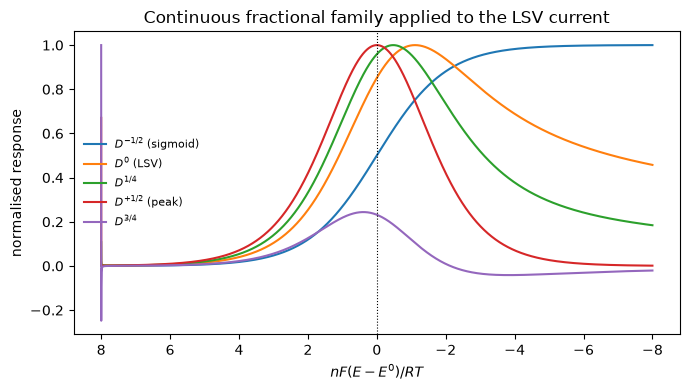

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
orders = [-0.5, 0.0, 0.25, 0.5, 0.75]
labels = {-0.5: r"$D^{-1/2}$ (sigmoid)", 0.0: r"$D^{0}$ (LSV)",
          0.25: r"$D^{1/4}$", 0.5: r"$D^{+1/2}$ (peak)",
          0.75: r"$D^{3/4}$"}
for q in orders:
    if q == 0.0:
        g = i_lsv.copy()
    else:
        g = fractional_integrodifferentiate(i_lsv, dtau, order=q)
    g = g / np.max(np.abs(g))   # normalise for shape comparison
    ax.plot(p, g, label=labels[q])
ax.axvline(0.0, ls=":", color="k", lw=0.8)
ax.invert_xaxis()
ax.set(xlabel="$nF(E-E^0)/RT$", ylabel="normalised response",
       title="Continuous fractional family applied to the LSV current")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## Summary

| Operator | Input | Output | Use |
|---|---|---|---|
| $D^{-1/2}$ semi-integral | Cottrell $t^{-1/2}$ | flat plateau $nFA\sqrt{D}c^*$ | concentration readout |
| $D^{-1/2}$ semi-integral | diffusion LSV peak | sigmoidal wave (Nernst $\theta$) | steady-state-equivalent $E^0$/n |
| $D^{+1/2}$ semi-derivative | diffusion LSV peak | symmetric peak at $E^0$ | resolution / overlapping waves |

All four operators reduce to the same Grünwald–Letnikov / Riemann–Liouville
convolution engine in `serm.semiintegration`, validated here against (1) the
analytic Cottrell plateau, (2) a sigmoid round-trip identity, (3) peak symmetry
and position, and (4) the gamma-function fractional power rule.
